In [1]:
def binary_search_verbose(arr, target):
    """
    Simple iterative binary search with verbose, line-by-line working out and justifications.
    Assumes `arr` is sorted in ascending order.
    Returns the index of target if found, otherwise returns -1.
    """
    low = 0
    high = len(arr) - 1
    step = 1 

    print(f"Start: searching for {target} in array of length {len(arr)}.")
    # Invariant justification: at each loop, if target is in arr it must be within indices [low, high].
    print("Invariant: if target exists in the array, it must be within the current [low, high] range.\n")

    while low <= high:
        mid = (low + high) // 2
        print(f"Step {step}: low={low}, high={high}, mid={mid}")
        print(f"  Value at mid: arr[{mid}] = {arr[mid]}; target = {target}")
        # Justify comparison
        print("  Justification: compare target to arr[mid] to decide which half can be discarded because the array is sorted.")

        if target == arr[mid]:
            print(f"  Result: target == arr[{mid}].")
            print(f"  Justification: found the target at index {mid}; algorithm terminates.\n")
            return mid

        if target < arr[mid]:
            # We discard right half including mid because arr[mid] > target and array is sorted.
            print(f"  Decision: target < arr[{mid}] -> discard indices >= {mid}.")
            print("  Justification: all elements to the right of mid are >= arr[mid] and thus > target, so they cannot contain the target.\n")
            high = mid - 1
        else:
            # target > arr[mid], discard left half including mid.
            print(f"  Decision: target > arr[{mid}] -> discard indices <= {mid}.")
            print("  Justification: all elements to the left of mid are <= arr[mid] and thus < target, so they cannot contain the target.\n")
            low = mid + 1

        step += 1

    # If we exit loop, low > high and target is not present.
    print("Termination: low > high, search interval empty.")
    print("Justification: if target were in the array it would be within [low, high]; since the interval is empty, the target is not present.\n")
    return -1


# Example usage (will run when this cell is executed in the notebook):
if __name__ == "__main__":
    arr = [1, 3, 5, 7, 9, 11]
    print("Example 1: target present")
    idx = binary_search_verbose(arr, 7)
    print(f"Returned index: {idx}\n")

    print("Example 2: target absent")
    idx = binary_search_verbose(arr, 4)
    print(f"Returned index: {idx}")

Example 1: target present
Start: searching for 7 in array of length 6.
Invariant: if target exists in the array, it must be within the current [low, high] range.

Step 1: low=0, high=5, mid=2
  Value at mid: arr[2] = 5; target = 7
  Justification: compare target to arr[mid] to decide which half can be discarded because the array is sorted.
  Decision: target > arr[2] -> discard indices <= 2.
  Justification: all elements to the left of mid are <= arr[mid] and thus < target, so they cannot contain the target.

Step 2: low=3, high=5, mid=4
  Value at mid: arr[4] = 9; target = 7
  Justification: compare target to arr[mid] to decide which half can be discarded because the array is sorted.
  Decision: target < arr[4] -> discard indices >= 4.
  Justification: all elements to the right of mid are >= arr[mid] and thus > target, so they cannot contain the target.

Step 3: low=3, high=3, mid=3
  Value at mid: arr[3] = 7; target = 7
  Justification: compare target to arr[mid] to decide which half

In [2]:
# New cell at index 1: readiness confirmation and show current variables
print("Ready.")
print("arr:", arr)
print("idx:", idx)

Ready.
arr: [1, 3, 5, 7, 9, 11]
idx: -1


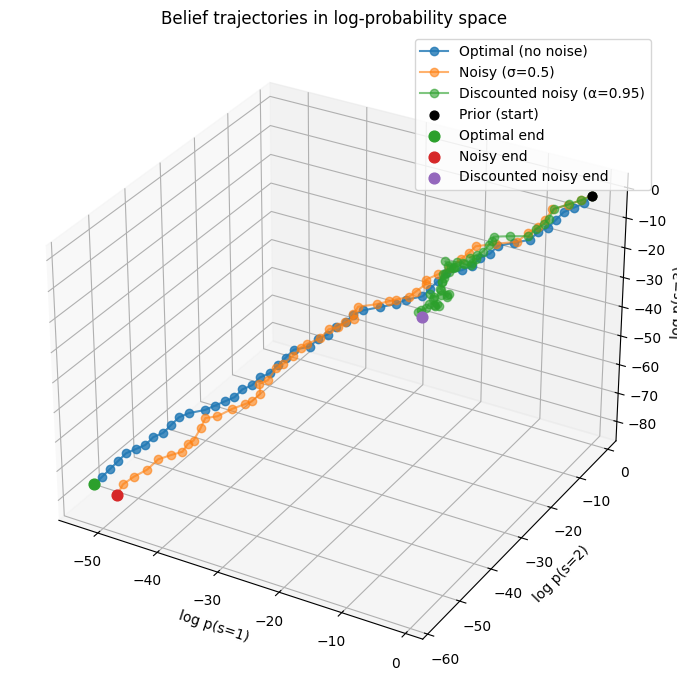

Final normalized posterior (optimal): [9.89120616e-01 1.08793837e-02 7.39286850e-11]
Final normalized posterior (noisy):   [9.86740341e-01 1.32596585e-02 5.91929459e-14]
Final normalized posterior (disc noisy): [9.68209347e-01 3.17902418e-02 4.11386111e-07]


In [7]:
from mpl_toolkits.mplot3d import Axes3D

# Simulation cell to be added at index 3
# Assumes `numpy as np`, `likelihoods`, `log_prior`, `T`, and `true_state` are already defined in the notebook.

import matplotlib.pyplot as plt

np.random.seed(0)

# Make likelihoods less polarising: apply a "softening" exponent (<1 moves rows toward uniform)
softness = 0.6  # 1.0 = original; smaller -> more uniform (choose in (0,1])
likelihoods = likelihoods ** softness
likelihoods = likelihoods / likelihoods.sum(axis=1, keepdims=True)

# Parameters
sigma = 0.5        # observation noise stddev added to each delta component
alpha = 0.95       # temporal discount factor (<= 1)

# Ensure shapes and types
n_states = likelihoods.shape[0]
assert likelihoods.shape == (n_states, n_states)  # square emission matrix
assert log_prior.shape[0] == n_states

# Sample an evidence sequence x_{1:T} from the true state
obs_seq_sim = np.random.choice(n_states, size=T, p=likelihoods[true_state, :])

# Helper: delta for observation x is vector [log P(x|s=1), ..., log P(x|s=n)]
def delta_for_obs(x):
    return np.log(likelihoods[:, x])

# Paths: store log-posteriors at each time (including t=0 prior)
path_opt = np.zeros((T + 1, n_states))
path_noisy = np.zeros((T + 1, n_states))
path_disc_noisy = np.zeros((T + 1, n_states))  # discounted noisy evidence

path_opt[0] = log_prior.copy()
path_noisy[0] = log_prior.copy()
path_disc_noisy[0] = log_prior.copy()

# For discounted sum we maintain the discounted sum of deltas
disc_sum = np.zeros(n_states)

for t in range(1, T + 1):
    x = obs_seq_sim[t - 1]
    d = delta_for_obs(x)

    # optimal (no noise, no discount)
    path_opt[t] = path_opt[t - 1] + d

    # noisy (add Gaussian noise to each delta component)
    eps = np.random.normal(0.0, sigma, size=n_states)
    d_noisy = d + eps
    path_noisy[t] = path_noisy[t - 1] + d_noisy

    # discounted noisy: maintain decayed sum of deltas
    disc_sum = alpha * disc_sum + d_noisy
    path_disc_noisy[t] = log_prior + disc_sum

# Plot trajectories in 3D (axes are log p(s=1), log p(s=2), log p(s=3))
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(path_opt[:, 0], path_opt[:, 1], path_opt[:, 2], '-o', label='Optimal (no noise)', alpha=0.8)
ax.plot(path_noisy[:, 0], path_noisy[:, 1], path_noisy[:, 2], '-o', label=f'Noisy (σ={sigma})', alpha=0.6)
ax.plot(path_disc_noisy[:, 0], path_disc_noisy[:, 1], path_disc_noisy[:, 2], '-o', label=f'Discounted noisy (α={alpha})', alpha=0.6)

# Mark start and end points
ax.scatter(path_opt[0,0], path_opt[0,1], path_opt[0,2], color='k', s=40, label='Prior (start)')
ax.scatter(path_opt[-1,0], path_opt[-1,1], path_opt[-1,2], color='tab:green', s=60, label='Optimal end')
ax.scatter(path_noisy[-1,0], path_noisy[-1,1], path_noisy[-1,2], color='tab:red', s=60, label='Noisy end')
ax.scatter(path_disc_noisy[-1,0], path_disc_noisy[-1,1], path_disc_noisy[-1,2], color='tab:purple', s=60, label='Discounted noisy end')

ax.set_xlabel('log p(s=1)')
ax.set_ylabel('log p(s=2)')
ax.set_zlabel('log p(s=3)')
ax.set_title('Belief trajectories in log-probability space')
ax.legend()
plt.tight_layout()
plt.show()

# Also print a short summary of final beliefs (converted to normalized probabilities)
def normalize_logp(logp):
    a = logp - np.max(logp)
    p = np.exp(a)
    return p / p.sum()

print("Final normalized posterior (optimal):", normalize_logp(path_opt[-1]))
print("Final normalized posterior (noisy):  ", normalize_logp(path_noisy[-1]))
print("Final normalized posterior (disc noisy):", normalize_logp(path_disc_noisy[-1]))

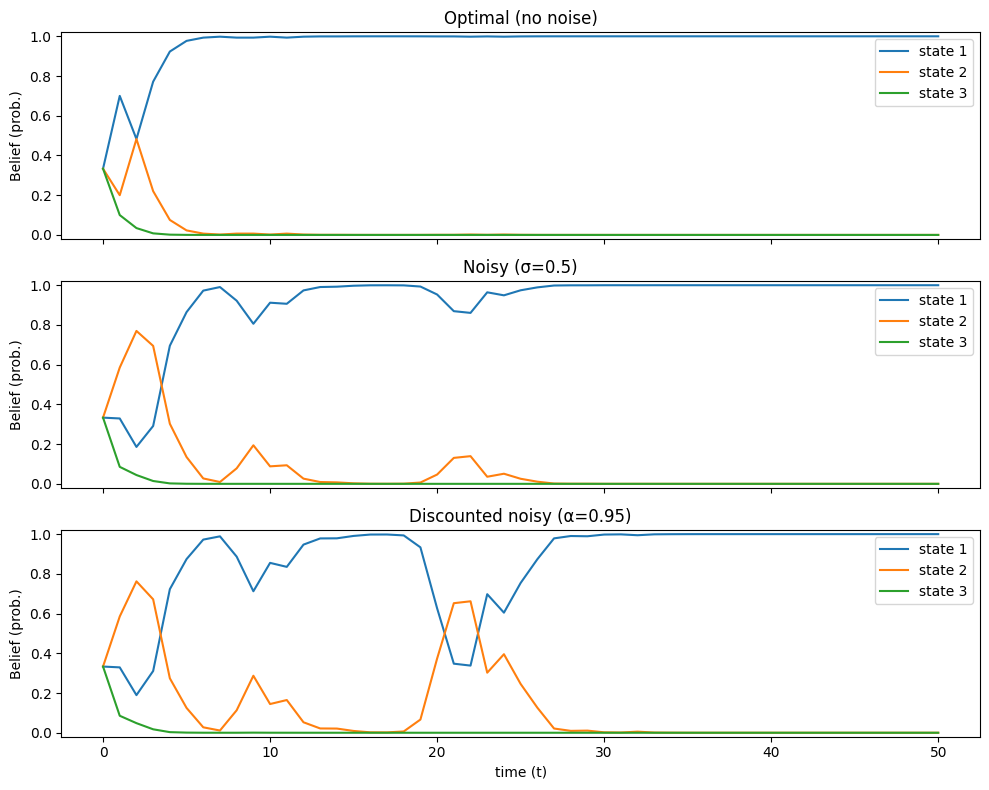

In [ ]:
# Plot time series of normalized beliefs for each of the three states
# Uses existing arrays: path_opt, path_noisy, path_disc_noisy, np, T

def normalize_logp_array(logp_array):
    # Convert array of log-probabilities (shape (T+1, n_states)) to probabilities row-wise
    a = logp_array - np.max(logp_array, axis=1, keepdims=True)
    p = np.exp(a)
    return p / p.sum(axis=1, keepdims=True)

p_opt = normalize_logp_array(path_opt)
p_noisy = normalize_logp_array(path_noisy)
p_disc = normalize_logp_array(path_disc_noisy)

times = np.arange(p_opt.shape[0])

fig2, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

colors = ['tab:blue', 'tab:orange', 'tab:green']
titles = ['Optimal (no noise)', f'Noisy (σ={sigma})', f'Discounted noisy (α={alpha})']
probs = [p_opt, p_noisy, p_disc]

for ax_, p, title in zip(axes, probs, titles):
    for i, c in enumerate(colors):
        ax_.plot(times, p[:, i], label=f'state {i+1}', color=c)
    ax_.set_ylim(-0.02, 1.02)
    ax_.set_ylabel('Belief (prob.)')
    ax_.set_title(title)
    ax_.legend(loc='upper right')

axes[-1].set_xlabel('time (t)')
plt.tight_layout()
plt.show()
